In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, recall_score, roc_curve,
                             brier_score_loss, precision_recall_curve,
                             average_precision_score)
from sklearn.calibration import calibration_curve
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
# 随机种子
RANDOM_STATE = 42
N_SAMPLES = 80000  # 采样样本数 (平衡计算开销与统计可靠性)

# 数据加载与特征选择

In [4]:
print("\n[0] 加载数据与特征选择...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')

df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

print(f"    有标签样本: {len(df):,}")

# === 选择特征 ===
# 原则: 兼顾缺失率、数据类型、临床意义
features_config = {
    'Age': 'numerical',           # 0.15% 缺失 — 连续数值
    'year': 'numerical',          # 0.00% 缺失 — 连续数值
    'Gender': 'categorical',      # ~0% 缺失 — 二分类
    'Diagnostic.means': 'categorical',  # 0.36% 缺失 — 诊断方式(7类)
    'Raca.Color': 'categorical',  # 15.31% 缺失 — 人种(5类)
}

feature_names = list(features_config.keys())
numerical_features = [k for k, v in features_config.items() if v == 'numerical']
categorical_features = [k for k, v in features_config.items() if v == 'categorical']

print(f"\n    所选特征: {feature_names}")
print(f"    数值型: {numerical_features}")
print(f"    分类型: {categorical_features}")

# 采样
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    sample_idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df_sample = df.iloc[sample_idx].copy()
else:
    df_sample = df.copy()

print(f"    分析样本量: {len(df_sample):,}")
print(f"    VIVO: {(df_sample['target'] == 1).sum():,} ({(df_sample['target'] == 1).mean() * 100:.2f}%)")
print(f"    MORTO: {(df_sample['target'] == 0).sum():,} ({(df_sample['target'] == 0).mean() * 100:.2f}%)")

# 显示所选特征的缺失情况
missing_info = []
for col in feature_names:
    n_miss = df_sample[col].isnull().sum()
    pct_miss = n_miss / len(df_sample) * 100
    missing_info.append({'Feature': col, 'Missing': n_miss, 'Pct': pct_miss})
    print(f"      {col:<20} 缺失: {n_miss:>6,} ({pct_miss:.2f}%)")



[0] 加载数据与特征选择...
    有标签样本: 209,758

    所选特征: ['Age', 'year', 'Gender', 'Diagnostic.means', 'Raca.Color']
    数值型: ['Age', 'year']
    分类型: ['Gender', 'Diagnostic.means', 'Raca.Color']
    分析样本量: 80,000
    VIVO: 32,845 (41.06%)
    MORTO: 47,155 (58.94%)
      Age                  缺失:    117 (0.15%)
      year                 缺失:      0 (0.00%)
      Gender               缺失:      0 (0.00%)
      Diagnostic.means     缺失:    286 (0.36%)
      Raca.Color           缺失: 12,250 (15.31%)


# 数据划分与预处理

In [5]:
print("\n[1] 数据集划分与编码...")

X = df_sample[feature_names].copy()
y = df_sample['target'].values

# 划分训练集/测试集 (stratify 保持标签分布)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"    训练集: {len(X_train):,} (VIVO: {y_train.sum():,})")
print(f"    测试集: {len(X_test):,} (VIVO: {y_test.sum():,})")

# 保存原始缺失索引用于后续分析
train_missing_mask = X_train.isnull()
test_missing_mask = X_test.isnull()

# 对分类型特征进行 Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # 用训练集拟合编码器
    non_null_train = X_train[col].dropna()
    le.fit(non_null_train.astype(str))

    # 处理测试集中的新类别: 替换为训练集中最常见的类别
    most_common = non_null_train.value_counts().index[0]

    def transform_with_unknown(x):
        if pd.isna(x):
            return np.nan
        x_str = str(x)
        if x_str in le.classes_:
            return le.transform([x_str])[0]
        else:
            return le.transform([most_common])[0]

    X_train[col] = X_train[col].apply(transform_with_unknown)
    X_test[col] = X_test[col].apply(transform_with_unknown)
    label_encoders[col] = le

# 转换为浮点数
X_train = X_train.astype(float)
X_test = X_test.astype(float)


[1] 数据集划分与编码...
    训练集: 56,000 (VIVO: 22,992.0)
    测试集: 24,000 (VIVO: 9,853.0)


# 四种策略: 插补 + 建模 + 评估

In [6]:
print("\n" + "=" * 70)
print("[2] 执行插补策略比较...")
print("=" * 70)

methods = {
    'Complete Case': {
        'desc': '完整案例分析 (删除含缺失的行)',
        'imputer': None,
        'color': '#7f8c8d'
    },
    'Mean Imputation': {
        'desc': '均值插补 (数值:均值 / 分类:众数)',
        'imputer': SimpleImputer(strategy='mean'),
        'color': '#3498db'
    },
    'KNN Imputation': {
        'desc': 'KNN 插补 (n_neighbors=5)',
        'imputer': KNNImputer(n_neighbors=5, weights='distance'),
        'color': '#e67e22'
    },
    'MICE Imputation': {
        'desc': 'MICE 多重插补 (IterativeImputer)',
        'imputer': IterativeImputer(max_iter=10, random_state=RANDOM_STATE),
        'color': '#9b59b6'
    }
}

results = []
models = {}
imputed_datasets = {}

for method_name, config in methods.items():
    print(f"\n  ▶ {method_name}: {config['desc']}")

    start_time = time.time()

    if method_name == 'Complete Case':
        # 删除任何含缺失的行
        train_mask = X_train.isnull().any(axis=1)
        test_mask = X_test.isnull().any(axis=1)

        X_train_imp = X_train[~train_mask].copy()
        y_train_imp = y_train[~train_mask]
        X_test_imp = X_test[~test_mask].copy()
        y_test_imp = y_test[~test_mask]

        n_dropped_train = train_mask.sum()
        n_dropped_test = test_mask.sum()
        print(f"      训练集删除: {n_dropped_train:,} 行 (保留 {len(X_train_imp):,})")
        print(f"      测试集删除: {n_dropped_test:,} 行 (保留 {len(X_test_imp):,})")
    else:
        # 插补
        imp = config['imputer']
        X_train_imp = pd.DataFrame(
            imp.fit_transform(X_train),
            columns=feature_names,
            index=X_train.index
        )
        X_test_imp = pd.DataFrame(
            imp.transform(X_test),
            columns=feature_names,
            index=X_test.index
        )
        y_train_imp = y_train
        y_test_imp = y_test

    imputed_datasets[method_name] = (X_train_imp, X_test_imp, y_train_imp, y_test_imp)

    # 标准化 (仅数值特征)
    scaler = StandardScaler()
    if method_name == 'Complete Case':
        # 对完整案例分析，需要分别处理数值列
        num_cols_train = [c for c in numerical_features if c in X_train_imp.columns]
    else:
        num_cols_train = numerical_features

    if num_cols_train:
        X_train_imp[num_cols_train] = scaler.fit_transform(X_train_imp[num_cols_train])
        X_test_imp[num_cols_train] = scaler.transform(X_test_imp[num_cols_train])

    # 训练逻辑回归
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    )
    lr.fit(X_train_imp, y_train_imp)

    # 预测
    y_pred_proba = lr.predict_proba(X_test_imp)[:, 1]
    y_pred = lr.predict(X_test_imp)

    # 评估: AUC
    auc = roc_auc_score(y_test_imp, y_pred_proba)

    # 评估: Recall (VIVO)
    recall = recall_score(y_test_imp, y_pred, pos_label=1)

    # 评估: Brier Score (校准度)
    brier = brier_score_loss(y_test_imp, y_pred_proba)

    # 评估: Average Precision (PR-AUC)
    avg_precision = average_precision_score(y_test_imp, y_pred_proba)

    # 校准曲线数据
    prob_true, prob_pred = calibration_curve(
        y_test_imp, y_pred_proba, n_bins=10, strategy='uniform'
    )

    elapsed = time.time() - start_time

    results.append({
        'Method': method_name,
        'AUC': auc,
        'Recall': recall,
        'Brier_Score': brier,
        'Avg_Precision': avg_precision,
        'Training_Size': len(y_train_imp),
        'Test_Size': len(y_test_imp),
        'Time': elapsed,
        'Calibration_True': prob_true,
        'Calibration_Pred': prob_pred,
        'Coefficients': lr.coef_[0] if hasattr(lr, 'coef_') else None,
        'Model': lr,
        'Color': config['color']
    })

    print(f"      AUC = {auc:.4f} | Recall = {recall:.4f} | Brier = {brier:.4f}")
    print(f"      耗时: {elapsed:.1f}s")


[2] 执行插补策略比较...

  ▶ Complete Case: 完整案例分析 (删除含缺失的行)
      训练集删除: 8,730 行 (保留 47,270)
      测试集删除: 3,787 行 (保留 20,213)
      AUC = 0.8644 | Recall = 0.9240 | Brier = 0.1493
      耗时: 0.0s

  ▶ Mean Imputation: 均值插补 (数值:均值 / 分类:众数)
      AUC = 0.8632 | Recall = 0.9236 | Brier = 0.1466
      耗时: 0.0s

  ▶ KNN Imputation: KNN 插补 (n_neighbors=5)
      AUC = 0.8628 | Recall = 0.9237 | Brier = 0.1467
      耗时: 23.3s

  ▶ MICE Imputation: MICE 多重插补 (IterativeImputer)
      AUC = 0.8637 | Recall = 0.9223 | Brier = 0.1462
      耗时: 0.1s


In [7]:
print("\n" + "=" * 70)
print("[3] 结果对比")
print("=" * 70)

results_df = pd.DataFrame(results)

print(f"\n  {'方法':<20} {'AUC':>8} {'Recall':>8} {'Brier':>8} {'PR-AUC':>8} {'样本量':>8} {'耗时':>8}")
print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
for _, row in results_df.iterrows():
    print(f"  {row['Method']:<20} {row['AUC']:>8.4f} {row['Recall']:>8.4f} "
          f"{row['Brier_Score']:>8.4f} {row['Avg_Precision']:>8.4f} "
          f"{int(row['Training_Size']):>8,} {row['Time']:>7.1f}s")


[3] 结果对比

  方法                        AUC   Recall    Brier   PR-AUC      样本量       耗时
  -------------------- -------- -------- -------- -------- -------- --------
  Complete Case          0.8644   0.9240   0.1493   0.6879   47,270     0.0s
  Mean Imputation        0.8632   0.9236   0.1466   0.7256   56,000     0.0s
  KNN Imputation         0.8628   0.9237   0.1467   0.7247   56,000    23.3s
  MICE Imputation        0.8637   0.9223   0.1462   0.7263   56,000     0.1s


  [图] 06a_performance_comparison.png → 性能对比柱状图已保存


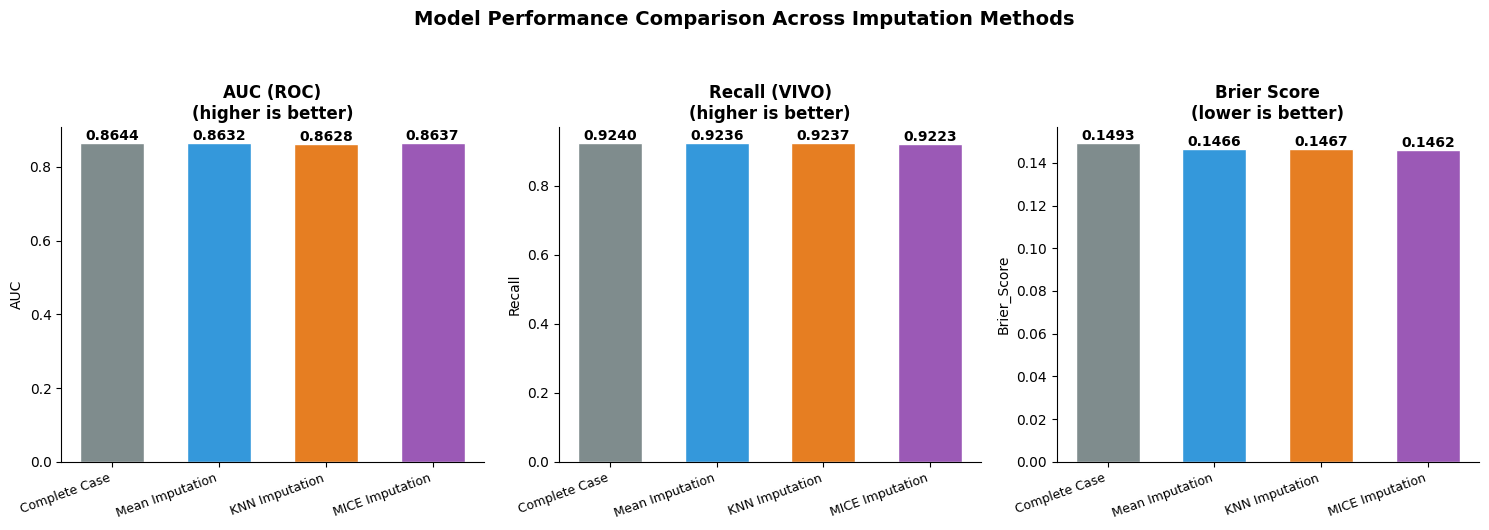

In [8]:

# --- 图 6a: AUC + Recall + Brier Score 对比柱状图 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = [
    ('AUC', 'AUC (ROC)', 'higher is better', False),
    ('Recall', 'Recall (VIVO)', 'higher is better', False),
    ('Brier_Score', 'Brier Score', 'lower is better', True),
]

for ax, (metric, title, note, invert) in zip(axes, metrics_to_plot):
    methods_names = [r['Method'] for r in results]
    values = [r[metric] for r in results]
    colors = [r['Color'] for r in results]

    bars = ax.bar(methods_names, values, color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'{title}\n({note})', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(methods_names, rotation=20, ha='right', fontsize=9)

plt.suptitle('Model Performance Comparison Across Imputation Methods',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "06a_performance_comparison.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 06a_performance_comparison.png → 性能对比柱状图已保存")

  [图] 06b_roc_curves.png → ROC曲线对比图已保存


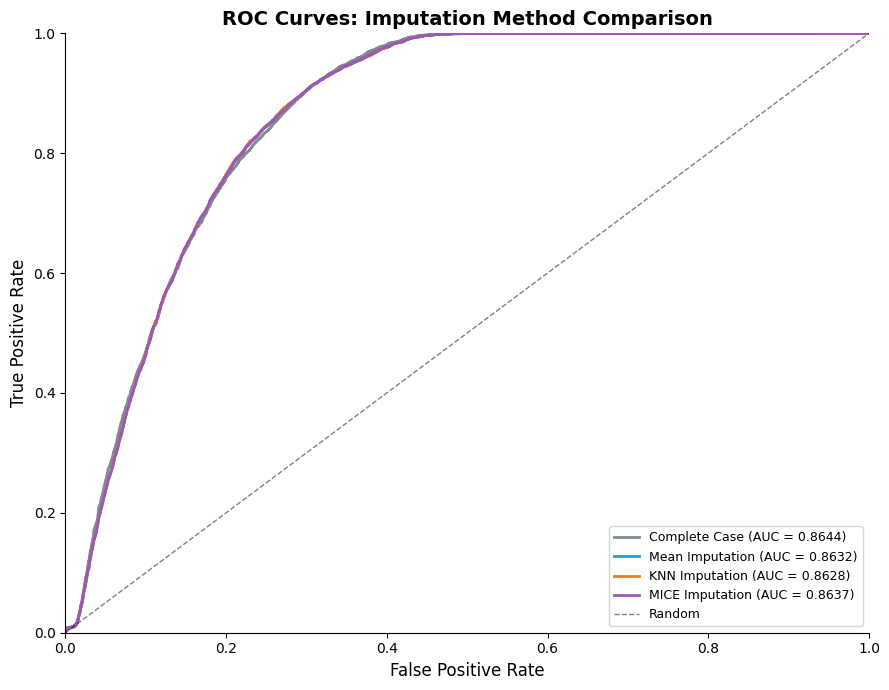

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

for r in results:
    method = r['Method']
    color = r['Color']
    X_t, _, y_t, _ = imputed_datasets[method]
    # 需要重新预测概率
    lr = r['Model']
    y_prob_roc = lr.predict_proba(X_test_imp if method != 'Complete Case'
                                   else imputed_datasets['Complete Case'][1])[:, 1]
    y_true_roc = (y_test_imp if method != 'Complete Case'
                  else imputed_datasets['Complete Case'][3])

    fpr, tpr, _ = roc_curve(y_true_roc, y_prob_roc)
    auc_val = r['AUC']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{method} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Imputation Method Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "06b_roc_curves.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 06b_roc_curves.png → ROC曲线对比图已保存")


  [图] 06c_calibration_curves.png → 校准曲线图已保存


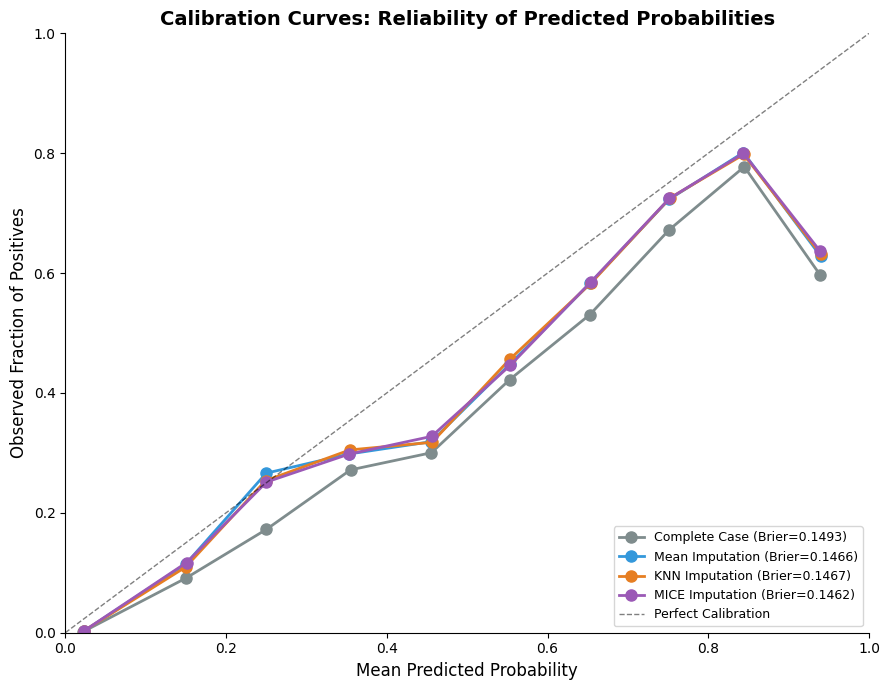

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

for r in results:
    ax.plot(r['Calibration_Pred'], r['Calibration_True'],
            marker='o', color=r['Color'], linewidth=2, markersize=8,
            label=f"{r['Method']} (Brier={r['Brier_Score']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Observed Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves: Reliability of Predicted Probabilities',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "06c_calibration_curves.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 06c_calibration_curves.png → 校准曲线图已保存")


  [图] 06d_training_size.png → 训练集规模对比图已保存


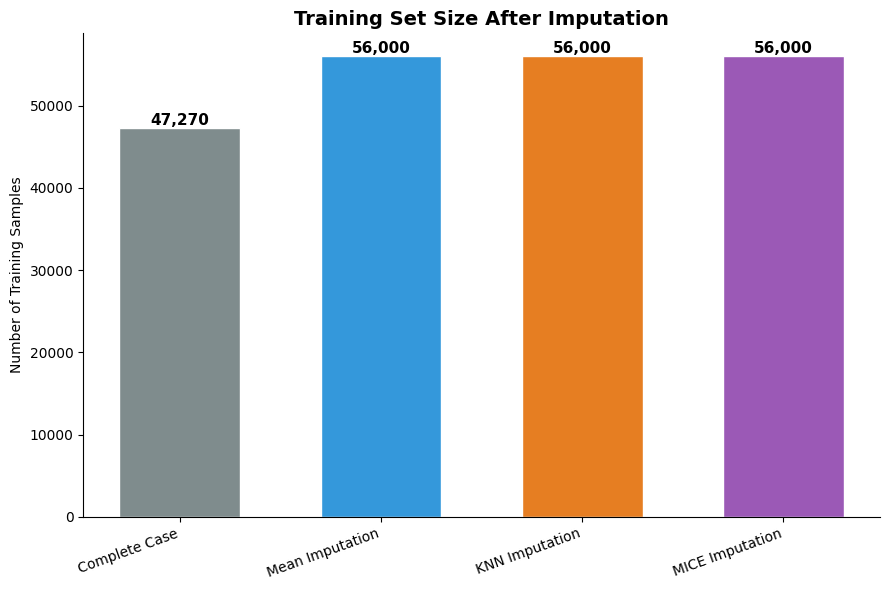

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
methods_names = [r['Method'] for r in results]
train_sizes = [r['Training_Size'] for r in results]
colors = [r['Color'] for r in results]

bars = ax.bar(methods_names, train_sizes, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, train_sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Training Set Size After Imputation', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Training Samples')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels(methods_names, rotation=20, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "06d_training_size.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 06d_training_size.png → 训练集规模对比图已保存")

  [图] 06e_distribution_impact.png → 插补对分布的影响图已保存


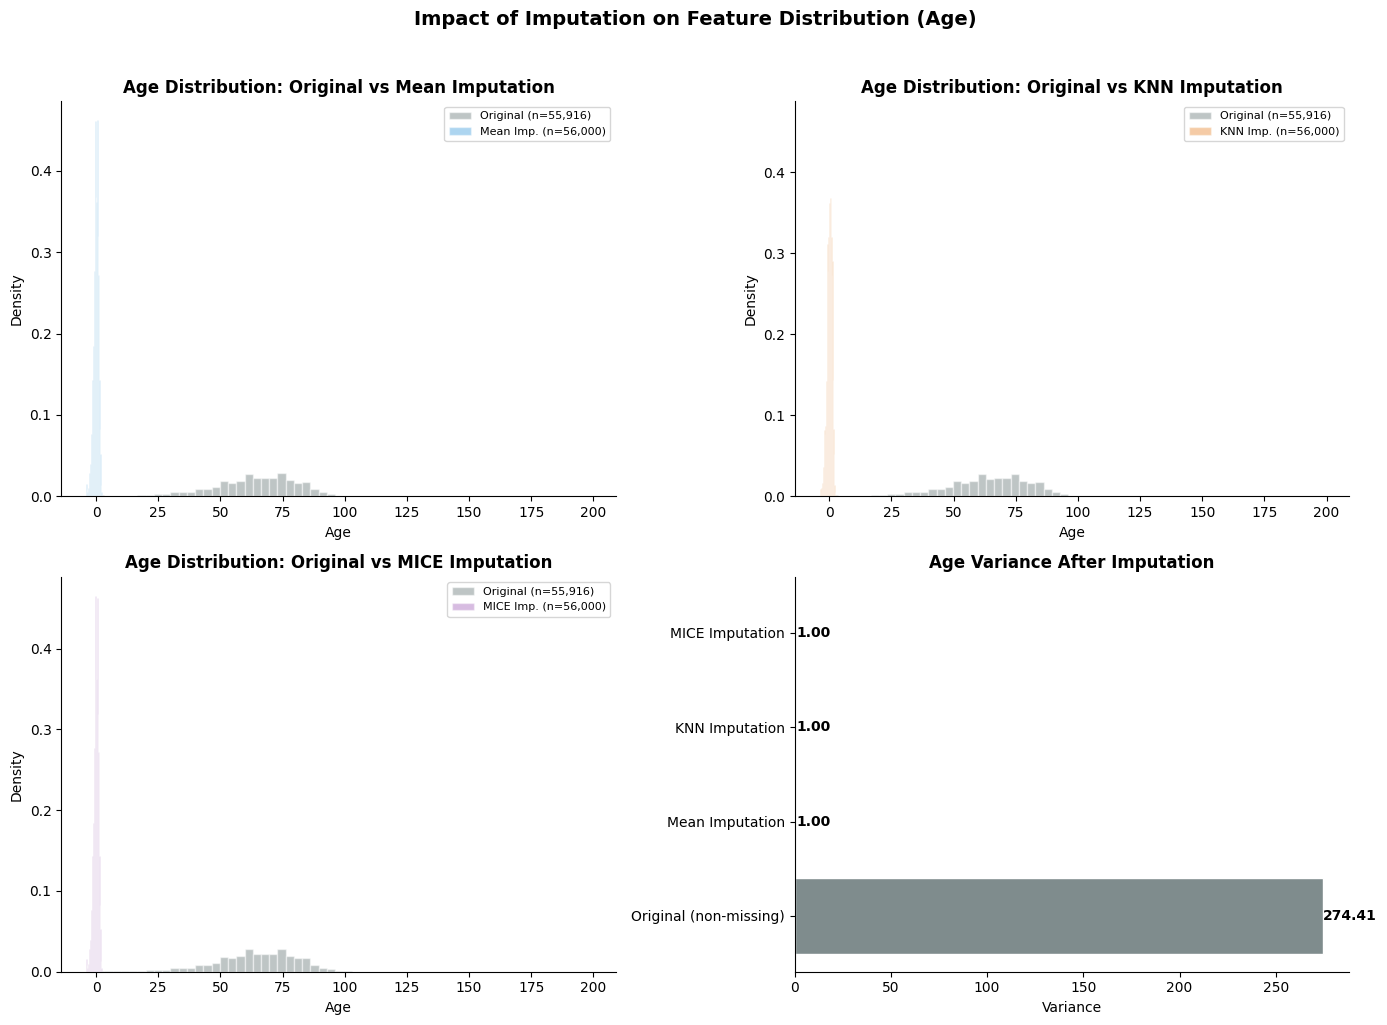

In [12]:

# --- 图 6e: 插补前后分布对比 (以 Age 为例) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 获取 Age 列在各个插补数据集中的分布
age_data = {}
for method_name in ['Mean Imputation', 'KNN Imputation', 'MICE Imputation']:
    X_train_imp, _, _, _ = imputed_datasets[method_name]
    age_data[method_name] = X_train_imp['Age']

# 原始 Age (Complete Case 用训练集)
age_original = X_train.dropna(subset=['Age'])['Age']

# 子图 1: 直方图对比
ax = axes[0, 0]
ax.hist(age_original, bins=60, alpha=0.5, density=True,
        color='#7f8c8d', label=f'Original (n={len(age_original):,})', edgecolor='white')
ax.hist(age_data['Mean Imputation'], bins=60, alpha=0.4, density=True,
        color='#3498db', label=f'Mean Imp. (n={len(age_data["Mean Imputation"]):,})', edgecolor='white')
ax.set_title('Age Distribution: Original vs Mean Imputation', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[0, 1]
ax.hist(age_original, bins=60, alpha=0.5, density=True,
        color='#7f8c8d', label=f'Original (n={len(age_original):,})', edgecolor='white')
ax.hist(age_data['KNN Imputation'], bins=60, alpha=0.4, density=True,
        color='#e67e22', label=f'KNN Imp. (n={len(age_data["KNN Imputation"]):,})', edgecolor='white')
ax.set_title('Age Distribution: Original vs KNN Imputation', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1, 0]
ax.hist(age_original, bins=60, alpha=0.5, density=True,
        color='#7f8c8d', label=f'Original (n={len(age_original):,})', edgecolor='white')
ax.hist(age_data['MICE Imputation'], bins=60, alpha=0.4, density=True,
        color='#9b59b6', label=f'MICE Imp. (n={len(age_data["MICE Imputation"]):,})', edgecolor='white')
ax.set_title('Age Distribution: Original vs MICE Imputation', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 子图 2: 方差对比条形图
ax = axes[1, 1]
variances = []
var_labels = []
for method_name in ['Original (non-missing)', 'Mean Imputation', 'KNN Imputation', 'MICE Imputation']:
    if method_name == 'Original (non-missing)':
        variances.append(age_original.var())
    else:
        variances.append(age_data[method_name].var())
    var_labels.append(method_name)

colors_variance = ['#7f8c8d', '#3498db', '#e67e22', '#9b59b6']
bars = ax.barh(var_labels, variances, color=colors_variance, edgecolor='white')
for bar, val in zip(bars, variances):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Age Variance After Imputation', fontsize=12, fontweight='bold')
ax.set_xlabel('Variance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Impact of Imputation on Feature Distribution (Age)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "06e_distribution_impact.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 06e_distribution_impact.png → 插补对分布的影响图已保存")

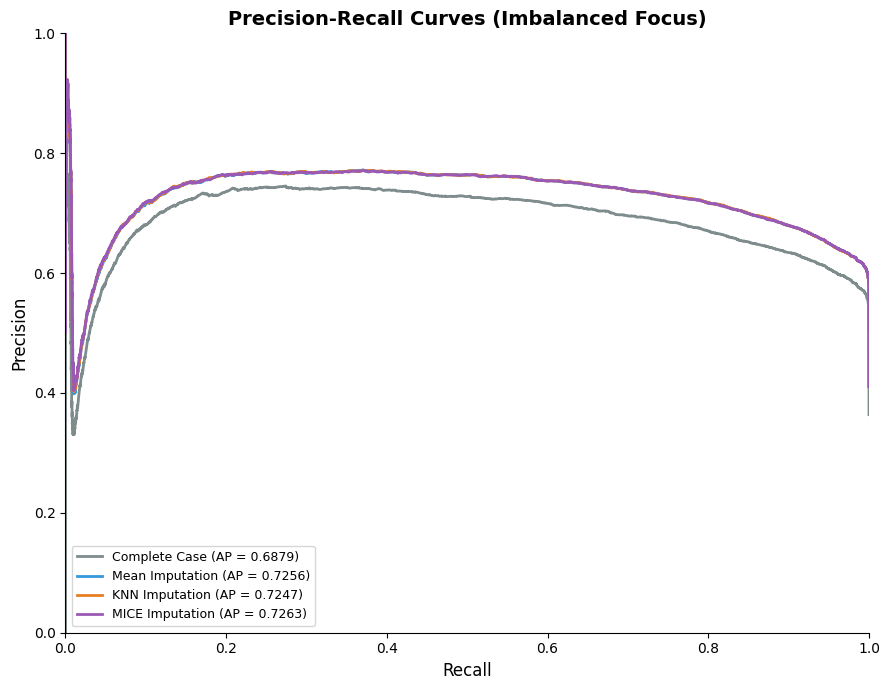

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

for r in results:
    method = r['Method']
    color = r['Color']
    X_t, _, y_t, _ = imputed_datasets[method]
    lr = r['Model']
    y_prob_pr = lr.predict_proba(X_test_imp if method != 'Complete Case'
                                  else imputed_datasets['Complete Case'][1])[:, 1]
    y_true_pr = (y_test_imp if method != 'Complete Case'
                 else imputed_datasets['Complete Case'][3])

    precision, recall, _ = precision_recall_curve(y_true_pr, y_prob_pr)
    ap = r['Avg_Precision']
    ax.plot(recall, precision, color=color, linewidth=2,
            label=f'{method} (AP = {ap:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (Imbalanced Focus)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "06f_pr_curves.png"), dpi=150, bbox_inches='tight')